In [1]:
# # Evandro Ribeiro Gomes Coelho
# # TCCII

# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics as m

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler 
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

from sklearn.model_selection import TimeSeriesSplit

In [2]:
# # import data

fl_path = 'data/'
fl_ext = '.csv'

fl_name = 'df_mlp'
df = pd.DataFrame(pd.read_csv(fl_path + fl_name + fl_ext, sep=','))

del fl_path, fl_ext, fl_name

In [3]:
df = df.set_index('Timestamp')
df['Value Prev'] = df.Value.shift(1)
df['Temperature Prev'] = df.Temperature.shift(1)
df = df.fillna(0)
df

,Value,Temperature,Holiday Flag,hour,min,time,hr_sin,hr_cos,Value Prev,Temperature Prev
Timestamp,,,,,,,,,,
2015-07-03 14:30:00+00:00,6997.984367,31.0,0.0,14,30,14.5,-0.608761,-0.793353,0.000000,0.0
2015-07-03 15:30:00+00:00,15518.012898,33.0,0.0,15,30,15.5,-0.793353,-0.608761,6997.984367,31.0
2015-07-03 16:30:00+00:00,6674.491991,34.0,0.0,16,30,16.5,-0.923880,-0.382683,15518.012898,33.0
2015-07-03 17:30:00+00:00,4920.282616,33.0,0.0,17,30,17.5,-0.991445,-0.130526,6674.491991,34.0
2015-07-03 18:30:00+00:00,4118.787012,34.0,0.0,18,30,18.5,-0.991445,0.130526,4920.282616,33.0
...,...,...,...,...,...,...,...,...,...,...
2017-11-08 09:30:00+00:00,9823.167728,6.0,0.0,9,30,9.5,0.608761,-0.793353,9907.625408,5.0
2017-11-08 10:30:00+00:00,9813.048374,6.0,0.0,10,30,10.5,0.382683,-0.923880,9823.167728,6.0
2017-11-08 11:30:00+00:00,11714.319199,7.0,0.0,11,30,11.5,0.130526,-0.991445,9813.048374,6.0


In [4]:
model = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(-1, 1), copy=True)),
    ('regressor', MLPRegressor(
    hidden_layer_sizes=(43,),  activation='tanh', solver='adam', alpha=0.001, batch_size='auto',
    learning_rate='constant', learning_rate_init=0.01, power_t=0.5, max_iter=1500, shuffle=True,
    random_state=0, tol=0.0001, verbose=False, warm_start=False, momentum=0, nesterovs_momentum=True,
    early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=3500))
])

In [5]:
# features
features = ['Temperature', 'Temperature Prev', 'Holiday Flag','Value Prev','hr_sin','hr_cos']
X = df[features].values
y = df['Value']

In [6]:
# spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1)

In [7]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(-1, 1))),
                ('regressor',
                 MLPRegressor(activation='tanh', alpha=0.001,
                              hidden_layer_sizes=(43,), learning_rate_init=0.01,
                              max_fun=3500, max_iter=1500, momentum=0,
                              random_state=0))])

In [8]:
model.score(X_test, y_test)

0.867697723811775

In [9]:
y_pred = model.predict(X_test)

Text(0.5, 1.0, 'Gráfico de Dispersão: Previsão x Teste')

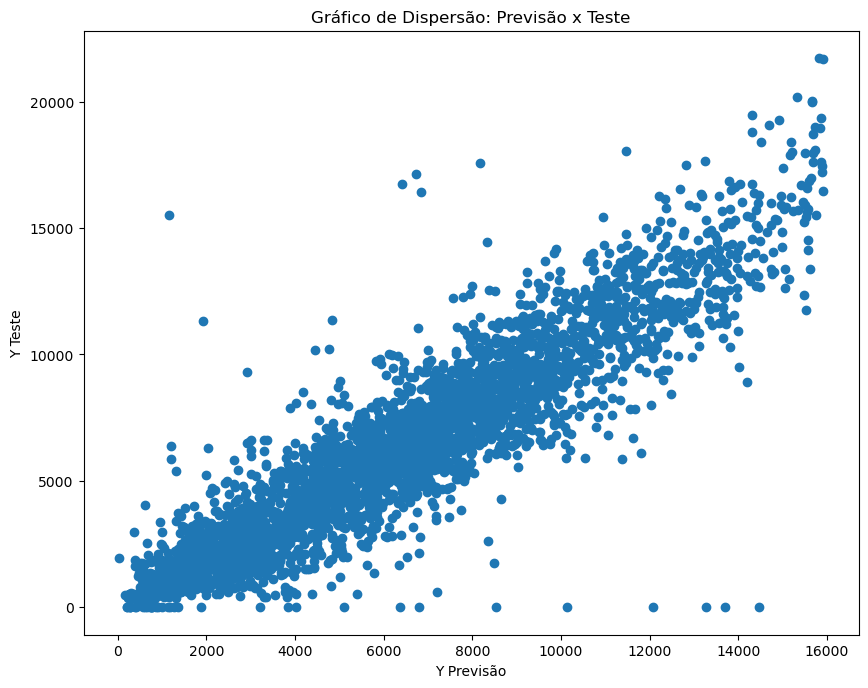

In [10]:
plt.figure(dpi=100, figsize=(10,8))
plt.scatter(y_pred,y_test)
plt.xlabel('Y Previsão')
plt.ylabel('Y Teste')
plt.title('Gráfico de Dispersão: Previsão x Teste')

In [11]:
y_pred

array([ 6607.66502024,  1205.53021355,  1083.02701654, ...,
         973.73394692,  2478.19150915, 10822.70181345])

In [12]:
residuals = y_test-y_pred
residuals.min()

-14461.191771275784

Text(0.5, 1.0, 'Histograma dos Resíduos')

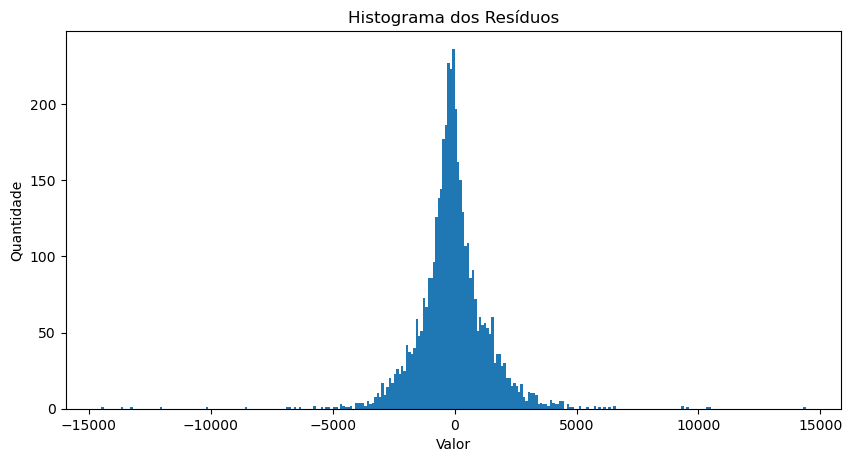

In [13]:
def compute_histogram_bins(data, desired_bin_size):
    min_val = np.min(data)
    max_val = np.max(data)
    min_boundary = -1.0 * (min_val % desired_bin_size - min_val)
    max_boundary = max_val - max_val % desired_bin_size + desired_bin_size
    n_bins = int((max_boundary - min_boundary) / desired_bin_size) + 1
    bins = np.linspace(min_boundary, max_boundary, n_bins)
    return bins

bins = compute_histogram_bins(residuals, 100.0)
plt.figure(dpi=100, figsize=(10,5))
plt.hist(residuals, bins=bins)
plt.xlabel('Valor')
plt.ylabel('Quantidade')
plt.title('Histograma dos Resíduos')

In [14]:
np.corrcoef(y_test,y_pred)

array([[1.        , 0.93175416],
       [0.93175416, 1.        ]])

In [15]:
# backup de calculo da media movel

In [16]:
df['Moving Average'] = df['Value'].rolling(window=5).mean()